<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_06_biomed_text/experiments/exp_06_biomed_text/CLIP_Biomed_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ6 — Biomedical text encoder ablation

3 × 2 ablation over `(text_encoder, prompt_strategy)`.

- **Encoders**: `bert-base-uncased`, `dmis-lab/biobert-v1.1`, `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract`.
- **Prompts**: `name_only`, `composed` (baseline format).

Image side, optimiser, loss, split and metrics are held identical to the v7 baseline (see `exp_01_baseline/`).

See `README.md` for the design rationale.


## 0 — Setup

The bootstrap below makes the notebook self-contained on Google Colab: it clones this repository at the `exp_06_biomed_text` branch (so the new `build_prompts` helper resolves), pins the TF / Keras / KerasHub stack to the versions used by the rest of the project, installs HuggingFace `transformers`, forces `KERAS_BACKEND=tensorflow` to avoid the JAX / `ml_dtypes` import conflict, and mounts Drive for persistent weight caching. Outside Colab the cell adds the local repo root to `sys.path` instead.


In [2]:
# --- Cell 0: bootstrap repo + dependencies + persistent storage ---
import os, sys, subprocess

# Force Keras 3 to use the TensorFlow backend. Must be set BEFORE any `import keras`.
# Without this Keras 3 may try to import JAX, and Colab's pre-installed jax expects
# ml_dtypes>=0.5 which conflicts with the ml_dtypes 0.4.x pinned by tensorflow 2.18.
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
# This notebook lives on a feature branch while RQ6 is in development. Clone
# that branch so `from src.prompts.templates import build_prompts` resolves.
# If the branch has been deleted (i.e. merged into main and cleaned up) the
# clone will fall back to main automatically — at that point this BRANCH
# variable can also be switched to "main" for clarity.
BRANCH = "exp_06_biomed_text"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    # Try to clone `branch`; fall back to main if the ref doesn't exist (post-merge).
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch '{branch}'")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch '{branch}' not found on origin; falling back to main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active_branch = _clone_with_fallback(BRANCH)
    else:
        # Already cloned; force-sync to the latest branch tip so reruns don't get stale code.
        # Try the feature branch first; fall back to main if its ref no longer exists.
        fetch = subprocess.run(
            ["git", "-C", REPO_DIR, "fetch", "origin", BRANCH],
            capture_output=True,
        )
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active_branch = BRANCH
        else:
            print(f"Branch '{BRANCH}' no longer on origin; resyncing to main")
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active_branch = "main"
    print(f"Active branch: {active_branch}")
    # Match v7 baseline TF/Keras/KerasHub pins + HuggingFace transformers for the text side.
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "transformers==4.46.0", "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    # Remove JAX so its ml_dtypes>=0.5 requirement doesn't fight with TF 2.18's
    # ml_dtypes 0.4.x pin. We don't use JAX here (KERAS_BACKEND=tensorflow above).
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)

    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    # Mount Drive for persistent weights cache.
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Active branch: exp_06_biomed_text
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports and reproducibility

All seeds and the TensorFlow op-determinism flag are set immediately after the imports, so anything random downstream (split, dataset shuffle, dropout) is bit-reproducible against the rest of the project (`SEED = 42`).


In [3]:
# --- Cell 1: imports ---
import os
# Belt-and-suspenders: re-assert before any keras import in case the bootstrap was skipped.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from transformers import AutoTokenizer, TFAutoModel

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import umap

# Repository helpers.
from src.utils.paths import is_colab, repo_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME,
    discover_records, stratified_split, save_split, load_split,
)
from src.prompts.templates import (
    BASELINE_TEMPLATE, ENSEMBLE_TEMPLATES,
    baseline_prompt, ensemble_prompts, build_prompts, PROMPT_STRATEGIES,
)
from src.eval.umap import fit_shared_umap, plot_umap_scatter, plot_umap_thumbnails


In [4]:
# --- Cell 2: reproducibility ---
SEED = 42
set_global_seed(SEED)
enable_op_determinism()


## 2 — Configuration and ablation grid

Hyperparameters match the v7 baseline exactly. The **only** knobs that vary across cells are `(text_encoder, prompt_strategy)`. The 6-cell `ABLATION_GRID` is the cross-product of three encoders and two prompt strategies; every other variable (image size, embedding dim, optimiser, schedule, split, loss, seed) is held identical.

`FORCE_RETRAIN = True` overrides the cached-weights short-circuit if you need to re-train a particular cell after changing code upstream.


In [5]:
# --- Cell 3: hyperparameters + ablation grid ---
EXPERIMENT = "exp_06_biomed_text"

# Image input.
IMG_SIZE = 224

# Text input.
# 32 has headroom for the longest ENSEMBLE_TEMPLATE on any of the three tokenizers.
MAX_LEN = 32

# Shared embedding space.
EMBED_DIM = 256

# Optimisation — held identical to v7 baseline.
BATCH_SIZE = 32
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LR = 1e-3
WD = 1e-4
GLOBAL_CLIPNORM = 1.0
INIT_TEMP = 0.07

# Performance.
AUTOTUNE = tf.data.AUTOTUNE

# Cache override.
FORCE_RETRAIN = False  # set True (locally or per-cell) to retrain even if weights exist on Drive

# Ablation grid.
ENCODERS = {
    "bert":    "bert-base-uncased",
    "biobert": "dmis-lab/biobert-v1.1",
    "pubmed":  "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
}
STRATEGIES = ("name_only", "composed")

ABLATION_GRID = [
    (f"{enc_key}_{strategy}", enc_id, strategy)
    for enc_key, enc_id in ENCODERS.items()
    for strategy in STRATEGIES
]

# Output directories.
SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
METRICS_DIR = results_dir("metrics") / EXPERIMENT
PLOTS_DIR = results_dir("plots") / EXPERIMENT
CM_DIR = results_dir("confusion_matrices") / EXPERIMENT
for d in (METRICS_DIR, PLOTS_DIR, CM_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Ablation grid:")
for cell_name, enc_id, strategy in ABLATION_GRID:
    print(f"  {cell_name:24s}  encoder={enc_id:60s}  strategy={strategy}")
print()
print("Split path:", SPLIT_PATH)
print("Metrics dir:", METRICS_DIR)


Ablation grid:
  bert_name_only            encoder=bert-base-uncased                                             strategy=name_only
  bert_composed             encoder=bert-base-uncased                                             strategy=composed
  biobert_name_only         encoder=dmis-lab/biobert-v1.1                                         strategy=name_only
  biobert_composed          encoder=dmis-lab/biobert-v1.1                                         strategy=composed
  pubmed_name_only          encoder=microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract          strategy=name_only
  pubmed_composed           encoder=microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract          strategy=composed

Split path: /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
Metrics dir: /content/histopathology-clip-lab/results/metrics/exp_06_biomed_text


## 3 — Dataset

LC25000 ([Borkowski et al. 2019](https://arxiv.org/abs/1912.12142v1)): 25,000 H&E patches at 768 × 768, 5 classes (`benign lung`, `lung_aca`, `lung_scc`, `benign colon`, `colon_aca`). `discover_records` walks the Kaggle download in deterministic order so the split below is reproducible from a seed alone.


In [6]:
# --- Cell 4: download dataset ---
import kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
print("Dataset root:", dataset_path)


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [7]:
# --- Cell 5: discover records ---
all_paths, all_indices = discover_records(dataset_path)
print(f"Discovered {len(all_paths)} images across {NUM_CLASSES} classes")


Discovered 23720 images across 5 classes


## 4 — Train / validation / test split

The stratified 80 / 10 / 10 split is computed once and saved to `results/splits/lc25000_seed42.json`. Every notebook in the project loads it identically so that comparisons across experiments are over the **same** test set — that's the entire point of this design.


In [8]:
# --- Cell 6: load the canonical 80/10/10 split (or rebuild if missing) ---
if SPLIT_PATH.exists():
    split = load_split(SPLIT_PATH)
    print("Loaded existing split from", SPLIT_PATH)
else:
    split = stratified_split(all_paths, all_indices,
                             val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(split, SPLIT_PATH)
    print("Built and saved new split at", SPLIT_PATH)

train_paths, train_idx = split["train_paths"], split["train_indices"]
val_paths,   val_idx   = split["val_paths"],   split["val_indices"]
test_paths,  test_idx  = split["test_paths"],  split["test_indices"]

print(f"train={len(train_paths)}  val={len(val_paths)}  test={len(test_paths)}")


Built and saved new split at /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
train=18976  val=2372  test=2372


## 5 — Prompt strategies

Two strategies, defined in `src.prompts.templates.build_prompts`:

- **`name_only`** — just the class name (e.g. `"benign lung tissue"`). Tests whether the encoder can classify on bare class vocabulary, with no scaffolding.
- **`composed`** — the v7 baseline template: `"A histopathology image of {class_name}."`. The control condition.

A third strategy (`multi_prompt`, training-time random pick over 5 `ENSEMBLE_TEMPLATES`) is supported by the data pipeline and `build_prompts` helper but is **not run by default** — under a frozen text encoder the 5 templates tokenize into near-identical embeddings, so the augmentation rarely moves the needle on a 5-class closed-set task. Re-enable by adding `"multi_prompt"` back to `STRATEGIES` if you want the data.

The cell below prints both strategies so you can verify the templates are what you expect before the multi-hour training loop kicks off.


In [9]:
# --- Cell 7: preview the three prompt strategies ---
for strategy in STRATEGIES:
    prompts = build_prompts(CLASS_NAMES, strategy)
    print(f"\n{strategy}:")
    if strategy == "multi_prompt":
        # list[list[str]] — show first class only
        print(f"  (5 templates per class; showing class 0 = {CLASS_NAMES[0]})")
        for t in prompts[0]:
            print(f"    {t}")
    else:
        for p in prompts:
            print(f"  {p}")



name_only:
  benign lung tissue
  lung adenocarcinoma
  lung squamous cell carcinoma
  benign colon tissue
  colon adenocarcinoma

composed:
  A histopathology image of benign lung tissue.
  A histopathology image of lung adenocarcinoma.
  A histopathology image of lung squamous cell carcinoma.
  A histopathology image of benign colon tissue.
  A histopathology image of colon adenocarcinoma.


## 6 — Text encoder factory

All three encoders are loaded through HuggingFace's `TFAutoModel` so the comparison is apples-to-apples: same tokenization stack, same TF integration, same projection-head interface. The factory returns `(model, tokenizer, hidden_size)` so the projection head can be sized without knowing in advance which encoder it's seeing.

`tokenize_prompts` is a thin wrapper that gives back `int32` TF tensors with shape `(N, MAX_LEN)`, ready to be indexed by class index inside the data pipeline.


In [10]:
# --- Cell 8: HuggingFace text encoder factory ---
# Returns (tf_model, tokenizer, hidden_size). The TF model is set non-trainable —
# we only train the projection head + logit_scale.

def load_text_encoder(encoder_id: str):
    tokenizer = AutoTokenizer.from_pretrained(encoder_id)
    # Several biomedical checkpoints (BioBERT v1.1, PubMedBERT) ship only PyTorch
    # weights on HF. The expected failure mode is OSError, but transformers 4.46.0
    # raises a TypeError when the sharded-TF-index lookup returns None — so we
    # catch broadly and fall back to PyTorch->TF conversion on any failure.
    try:
        tf_model = TFAutoModel.from_pretrained(encoder_id, from_pt=False)
    except (OSError, EnvironmentError, TypeError, ValueError):
        tf_model = TFAutoModel.from_pretrained(encoder_id, from_pt=True)
    tf_model.trainable = False
    hidden = tf_model.config.hidden_size
    return tf_model, tokenizer, hidden


def tokenize_prompts(tokenizer, prompts, max_len=MAX_LEN):
    """Tokenize a list of prompts -> dict of int32 TF tensors with shape (N, max_len)."""
    out = tokenizer(
        prompts,
        padding="max_length", truncation=True, max_length=max_len,
        return_tensors="tf",
    )
    return {k: tf.cast(v, tf.int32) for k, v in out.items()}


# Smoke-test the factory on a tiny prompt set
_test_enc_id = ENCODERS["bert"]
_m, _tok, _hidden = load_text_encoder(_test_enc_id)
_toks = tokenize_prompts(_tok, [baseline_prompt(c) for c in CLASS_NAMES])
print(f"{_test_enc_id}: hidden_size={_hidden}  tokens={ {k: v.shape for k, v in _toks.items()} }")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

bert-base-uncased: hidden_size=768  tokens={'input_ids': TensorShape([5, 32]), 'token_type_ids': TensorShape([5, 32]), 'attention_mask': TensorShape([5, 32])}


## 7 — Input pipelines

The training pipeline emits `((image, token_dict), class_index)`. Both `name_only` and `composed` use a deterministic class → token lookup (one prompt per class). The data builder also retains a `multi_prompt` branch for future use; it samples a random template per batch sample but is not exercised under the current `STRATEGIES`.

No image augmentation is applied: LC25000's authors already expanded 1,250 originals to 25,000 via rotation + flip, so additional geometric augmentation would be redundant. Photometric augmentation is left to RQ5 (stain normalisation).


In [11]:
# --- Cell 9: image loader (no augmentation) ---
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img


In [12]:
# --- Cell 10: dataset builders ---
# The dataset yields (image, token_dict) per sample. The token_dict is the
# tokenized prompt for that sample's class.
#
# - name_only / composed:  one prompt per class -> deterministic
# - multi_prompt:           per-sample random pick from ENSEMBLE_TEMPLATES
#
# At inference time we always compute embeddings for ALL ENSEMBLE_TEMPLATES per
# class and average them (for multi_prompt), or use the single class prompt.

def build_train_dataset(paths, indices, tokenizer, strategy, batch_size, shuffle=True):
    """Build a tf.data pipeline that yields ((image, token_dict), label_index)."""
    n = len(paths)
    paths_t = tf.constant(paths)
    idx_t = tf.constant(indices, dtype=tf.int32)

    # Pre-tokenize all candidate prompts so we can index them at sample time.
    if strategy == "multi_prompt":
        # Shape: (NUM_CLASSES, NUM_TEMPLATES, MAX_LEN) per key.
        per_class_per_template = build_prompts(CLASS_NAMES, "multi_prompt")  # list[list[str]]
        # Flatten -> tokenize -> reshape back
        flat = [t for class_list in per_class_per_template for t in class_list]
        tok_flat = tokenize_prompts(tokenizer, flat)
        n_templates = len(ENSEMBLE_TEMPLATES)
        token_lookup = {
            k: tf.reshape(v, (NUM_CLASSES, n_templates, MAX_LEN))
            for k, v in tok_flat.items()
        }
    else:
        # Shape: (NUM_CLASSES, MAX_LEN)
        prompts = build_prompts(CLASS_NAMES, strategy)
        tok_flat = tokenize_prompts(tokenizer, prompts)
        token_lookup = {k: v for k, v in tok_flat.items()}

    def map_fn(path, class_idx):
        img = load_image(path)
        if strategy == "multi_prompt":
            tmpl_idx = tf.random.uniform([], maxval=n_templates, dtype=tf.int32)
            token_dict = {k: v[class_idx, tmpl_idx] for k, v in token_lookup.items()}
        else:
            token_dict = {k: v[class_idx] for k, v in token_lookup.items()}
        return (img, token_dict), class_idx

    ds = tf.data.Dataset.from_tensor_slices((paths_t, idx_t))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(n, 10_000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(map_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def build_eval_image_dataset(paths, batch_size):
    """Iterates images for inference-time embedding."""
    ds = tf.data.Dataset.from_tensor_slices(tf.constant(paths))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


## 8 — Model

`CLIPModel_HF` is a thin clone of the v7 baseline's `CLIPModel` with the text-backbone interface adapted for HuggingFace. The image side is identical: KerasHub ResNet50, frozen, GAP, then a `Dense(256, no bias) → LayerNorm` projection. The text side takes `(input_ids, attention_mask[, token_type_ids])` from the HF tokenizer, runs the frozen `TFAutoModel`, prefers `pooler_output` when available and falls back to `last_hidden_state[:, 0]` otherwise, then projects to the same 256-d shared space.

The InfoNCE loss, the clamped `logit_scale` temperature, and the `train_step` / `test_step` are unchanged from the baseline. Trainable parameters are still just the two projection heads + the temperature scalar.


In [13]:
# --- Cell 11: CLIPModel_HF — like the baseline but with a HuggingFace text backbone ---

class CLIPModel_HF(keras.Model):
    def __init__(self, img_backbone, text_backbone, hidden_size,
                 embed_dim=EMBED_DIM, init_temp=INIT_TEMP, **kwargs):
        super().__init__(**kwargs)
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone
        self.hidden_size = hidden_size

        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")

        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")

        self.logit_scale = self.add_weight(
            name="logit_scale",
            shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True,
            dtype="float32",
        )
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, images, training=False):
        # Frozen backbone: keep BN running stats in inference mode.
        features = self.img_backbone(images, training=False)
        if features.shape.rank == 4:
            features = tf.reduce_mean(features, axis=[1, 2])
        x = self.img_projection(features)
        return tf.math.l2_normalize(x, axis=-1)

    def encode_text(self, token_dict, training=False):
        # HF TFAutoModel takes (input_ids, attention_mask[, token_type_ids]).
        kwargs = {"input_ids": token_dict["input_ids"],
                  "attention_mask": token_dict["attention_mask"]}
        if "token_type_ids" in token_dict:
            kwargs["token_type_ids"] = token_dict["token_type_ids"]
        out = self.text_backbone(**kwargs, training=False)
        # Prefer the pooled CLS-output where available; fall back to last_hidden_state[:, 0]
        pooled = getattr(out, "pooler_output", None)
        if pooled is None:
            pooled = out.last_hidden_state[:, 0, :]
        x = self.text_projection(pooled)
        return tf.math.l2_normalize(x, axis=-1)

    def _clip_loss(self, img_emb, txt_emb):
        img_emb = tf.cast(img_emb, tf.float32)
        txt_emb = tf.cast(txt_emb, tf.float32)
        logit_scale = tf.clip_by_value(self.logit_scale, -math.log(100.0), math.log(100.0))
        logits = tf.matmul(img_emb, txt_emb, transpose_b=True) * tf.exp(logit_scale)
        labels = tf.range(tf.shape(img_emb)[0], dtype=tf.int32)
        ce = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True, reduction=tf.keras.losses.Reduction.NONE,
        )
        loss_i = tf.reduce_mean(ce(labels, logits))
        loss_t = tf.reduce_mean(ce(labels, tf.transpose(logits)))
        return 0.5 * (loss_i + loss_t)

    def call(self, inputs, training=False):
        images, token_dict = inputs
        return self.encode_image(images, training=training), self.encode_text(token_dict, training=training)

    def train_step(self, data):
        (inputs, _y) = data  # the dataset emits a class index but the loss ignores it.
        with tf.GradientTape() as tape:
            img_emb, txt_emb = self(inputs, training=True)
            loss = self._clip_loss(img_emb, txt_emb)
        trainable = self.trainable_variables
        grads = tape.gradient(loss, trainable)
        self.optimizer.apply_gradients(zip(grads, trainable))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        (inputs, _y) = data
        img_emb, txt_emb = self(inputs, training=False)
        loss = self._clip_loss(img_emb, txt_emb)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


## 9 — Per-cell train + evaluate

Two routines, one per ablation cell:

- **`train_or_load_cell`** — checks for cached weights at `<RUN_DIR>/<cell>/weights.weights.h5`. If present (and `FORCE_RETRAIN=False`), loads them; otherwise trains from scratch with EarlyStopping(patience=5, restore_best_weights) and ReduceLROnPlateau, then saves both weights and history. The image backbone is instantiated once outside the loop because it's identical across cells.
- **`evaluate_cell`** — encodes all test images once, encodes the class prompts (one per class for the active strategies), runs `argmax` over `image @ prompt.T` for classification, and computes a `prompt_separation` diagnostic: the mean off-diagonal cosine *distance* between the 5 class-prompt embeddings. A small value flags the well-known short-prompt + frozen-text-encoder degeneracy where all class prompts collapse to a near-singular point — which acts as an upper bound on what the InfoNCE alignment can achieve.


In [14]:
# --- Cell 12: train_or_load_cell ---

# Image backbone is shared across all cells (no per-cell state). Build it once.
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
image_backbone.trainable = False


def train_or_load_cell(cell_name, encoder_id, strategy, force=False):
    """Trains the projection head for one (encoder, strategy) cell, or loads cached weights.
    Returns the trained model + the tokenizer used + the training history (or None if loaded)."""

    cell_run_dir = run_dir(EXPERIMENT, cell_name)
    # Keras 3 requires the weights-only checkpoint filename to end in `.weights.h5`.
    weights_path = cell_run_dir / "weights.weights.h5"
    history_path = cell_run_dir / "history.json"
    weights_exist = weights_path.exists()

    print(f"\n========== {cell_name} ==========")
    print(f"  encoder = {encoder_id}")
    print(f"  prompt  = {strategy}")
    print(f"  run dir = {cell_run_dir}")
    print(f"  weights present: {weights_exist}")

    text_backbone, tokenizer, hidden = load_text_encoder(encoder_id)
    model = CLIPModel_HF(image_backbone, text_backbone, hidden)

    optimizer = keras.optimizers.AdamW(
        learning_rate=LR, weight_decay=WD, global_clipnorm=GLOBAL_CLIPNORM,
    )
    model.compile(optimizer=optimizer)

    # Build the model so save/load works (need one forward pass to materialize weights).
    sample_ds = build_train_dataset(train_paths[:1], train_idx[:1], tokenizer, strategy,
                                    batch_size=1, shuffle=False)
    for inputs, _ in sample_ds.take(1):
        _ = model(inputs, training=False)

    if weights_exist and not force and not FORCE_RETRAIN:
        model.load_weights(weights_path)
        history = json.loads(history_path.read_text()) if history_path.exists() else None
        print(f"  -> loaded cached weights from {weights_path}")
        return model, tokenizer, history

    # Train from scratch.
    train_ds = build_train_dataset(train_paths, train_idx, tokenizer, strategy, BATCH_SIZE, shuffle=True)
    val_ds   = build_train_dataset(val_paths, val_idx, tokenizer, strategy, BATCH_SIZE, shuffle=False)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, verbose=1,
        ),
    ]

    history_obj = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        callbacks=callbacks, verbose=2,
    )

    cell_run_dir.mkdir(parents=True, exist_ok=True)
    model.save_weights(weights_path)
    history = {k: [float(v) for v in vs] for k, vs in history_obj.history.items()}
    history_path.write_text(json.dumps(history, indent=2))
    print(f"  -> saved weights to {weights_path}")
    return model, tokenizer, history


In [15]:
# --- Cell 13: evaluate_cell ---

def encode_test_images(model, paths):
    ds = build_eval_image_dataset(paths, BATCH_SIZE)
    out = []
    for batch in ds:
        emb = model.encode_image(batch, training=False)
        out.append(emb.numpy())
    return np.concatenate(out, axis=0)


def encode_class_prompts(model, tokenizer, strategy):
    """Returns (NUM_CLASSES, EMBED_DIM) class-prompt embeddings.
    For multi_prompt: encode all 5 templates per class, mean over templates, L2-renormalise."""
    if strategy == "multi_prompt":
        per_class_per_template = build_prompts(CLASS_NAMES, "multi_prompt")
        out = []
        for class_templates in per_class_per_template:
            toks = tokenize_prompts(tokenizer, class_templates)
            embs = model.encode_text(toks, training=False).numpy()  # (5, D)
            mean = embs.mean(axis=0)
            mean /= (np.linalg.norm(mean) + 1e-9)
            out.append(mean)
        return np.stack(out, axis=0)
    else:
        prompts = build_prompts(CLASS_NAMES, strategy)
        toks = tokenize_prompts(tokenizer, prompts)
        embs = model.encode_text(toks, training=False).numpy()
        embs = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-9)
        return embs


def evaluate_cell(cell_name, model, tokenizer, strategy):
    """Run all per-cell evaluation; returns a metrics dict and saves outputs to disk."""
    class_text_embeddings = encode_class_prompts(model, tokenizer, strategy)
    test_image_embeddings = encode_test_images(model, test_paths)
    true_class_ids = np.array(test_idx)

    sims = test_image_embeddings @ class_text_embeddings.T
    predicted_class_ids = sims.argmax(axis=1)

    acc      = accuracy_score(true_class_ids, predicted_class_ids)
    bal_acc  = balanced_accuracy_score(true_class_ids, predicted_class_ids)
    macro_f1 = f1_score(true_class_ids, predicted_class_ids, average="macro")
    wgt_f1   = f1_score(true_class_ids, predicted_class_ids, average="weighted")

    per_class_report = classification_report(
        true_class_ids, predicted_class_ids,
        labels=list(range(NUM_CLASSES)),
        target_names=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)],
        output_dict=True, zero_division=0,
    )

    cm_raw = confusion_matrix(true_class_ids, predicted_class_ids,
                              labels=list(range(NUM_CLASSES)))
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                        out=np.zeros_like(cm_raw, dtype=np.float64))

    # Prompt-separation diagnostic: mean off-diagonal cosine distance
    # between the 5 class-prompt embeddings.
    text_sim = class_text_embeddings @ class_text_embeddings.T
    off_diag = text_sim[~np.eye(NUM_CLASSES, dtype=bool)]
    prompt_separation = float(1.0 - off_diag.mean())  # higher = more separated

    metrics = {
        "cell_name": cell_name,
        "strategy": strategy,
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(wgt_f1),
        "prompt_separation": prompt_separation,
        "per_class": per_class_report,
    }

    # Persist
    (METRICS_DIR / f"{cell_name}_classification.json").write_text(json.dumps(metrics, indent=2))
    np.save(CM_DIR / f"{cell_name}_cm_raw.npy", cm_raw)
    np.save(CM_DIR / f"{cell_name}_cm_norm.npy", cm_norm)

    return metrics, test_image_embeddings, class_text_embeddings, predicted_class_ids


## 10 — Main ablation loop

Iterates every `(encoder, strategy)` cell in `ABLATION_GRID`. On a fresh run each cell trains for up to 30 epochs (EarlyStopping patience 5); on subsequent runs the loop loads cached weights and only re-runs evaluation. Per-cell results, image embeddings, and class-prompt embeddings are kept in memory for the cross-cell aggregation that follows.

**Cost estimate:** ~30 min/cell on a Colab L4 → ~3 h for the full 6-cell matrix. Cached subsequent runs are minutes.


In [16]:
# --- Cell 14: main loop over the 3x2 grid ---

all_results = {}
all_image_embeddings = {}
all_text_embeddings = {}

for cell_name, encoder_id, strategy in ABLATION_GRID:
    model, tokenizer, history = train_or_load_cell(cell_name, encoder_id, strategy)
    metrics, img_emb, txt_emb, _ = evaluate_cell(cell_name, model, tokenizer, strategy)
    all_results[cell_name] = metrics
    all_image_embeddings[cell_name] = img_emb
    all_text_embeddings[cell_name] = txt_emb

    print(f"  {cell_name}: macro_F1={metrics['macro_f1']:.4f}  prompt_sep={metrics['prompt_separation']:.4f}")



========== bert_name_only ==========
  encoder = bert-base-uncased
  prompt  = name_only
  run dir = /content/drive/MyDrive/clip_histopathology/exp_06_biomed_text/bert_name_only
  weights present: True


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

  -> loaded cached weights from /content/drive/MyDrive/clip_histopathology/exp_06_biomed_text/bert_name_only/weights.weights.h5
  bert_name_only: macro_F1=0.9987  prompt_sep=0.7203

========== bert_composed ==========
  encoder = bert-base-uncased
  prompt  = composed
  run dir = /content/drive/MyDrive/clip_histopathology/exp_06_biomed_text/bert_composed
  weights present: True


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

  -> loaded cached weights from /content/drive/MyDrive/clip_histopathology/exp_06_biomed_text/bert_composed/weights.weights.h5
  bert_composed: macro_F1=0.9987  prompt_sep=0.6103

========== biobert_name_only ==========
  encoder = dmis-lab/biobert-v1.1
  prompt  = name_only
  run dir = /content/drive/MyDrive/clip_histopathology/exp_06_biomed_text/biobert_name_only
  weights present: True


...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint

Epoch 1/30
593/593 - 75s - 127ms/step - loss: 2.0467 - val_loss: 1.9499 - learning_rate: 1.0000e-03
Epoch 2/30
593/593 - 53s - 90ms/step - loss: 1.9730 - val_loss: 1.9458 - learning_rate: 1.0000e-03
Epoch 3/30
593/593 - 54s - 90ms/step - loss: 1.9540 - val_loss: 1.9245 - learning_rate: 1.0000e-03
Epoch 4/30
593/593 - 54s - 90ms/step - loss: 1.9470 - val_loss: 1.9454 - learning_rate: 1.0000e-03
Epoch 5/30

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
593/593 - 54s - 91ms/step - loss: 1.9451 - val_loss: 1.9316 - learning_rate: 1.0000e-03
Epoch 6/30
593/593 - 54s - 91ms/step - loss: 1.9408 - val_loss: 1.9194 - learning_rate: 5.0000e-04
Epoch 7/30
593/593 - 54s - 91ms/step - loss: 1.9313 - val_loss: 1.9183 - learning_rate: 5.0000e-04
Epoch 8/30
593/593 - 54s - 91ms/step - loss: 1.9320 - val_loss: 1.9187 - learning_rate: 5.0000e-04
Epoch 9/30

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
593/593 - 54s - 91ms/step - loss: 1.9308 -

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint

Epoch 1/30
593/593 - 75s - 127ms/step - loss: 2.0911 - val_loss: 1.9478 - learning_rate: 1.0000e-03
Epoch 2/30
593/593 - 54s - 91ms/step - loss: 1.9842 - val_loss: 1.9286 - learning_rate: 1.0000e-03
Epoch 3/30
593/593 - 54s - 91ms/step - loss: 1.9592 - val_loss: 1.9374 - learning_rate: 1.0000e-03
Epoch 4/30

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
593/593 - 54s - 91ms/step - loss: 1.9527 - val_loss: 1.9299 - learning_rate: 1.0000e-03
Epoch 5/30
593/593 - 54s - 91ms/step - loss: 1.9420 - val_loss: 1.9239 - learning_rate: 5.0000e-04
Epoch 6/30
593/593 - 54s - 91ms/step - loss: 1.9432 - val_loss: 1.9210 - learning_rate: 5.0000e-04
Epoch 7/30
593/593 - 54s - 91ms/step - loss: 1.9350 - val_loss: 1.9218 - learning_rate: 5.0000e-04
Epoch 8/30
593/593 - 54s - 91ms/step - loss: 1.9358 - val_loss: 1.9206 - learning_rate: 5.0000e-04
Epoch 9/30
593/593 - 54s - 91ms/step - loss: 1.9342 - val_loss: 1.9191 - learning_rate: 5.0000e-04
Epoch 10/30
593/593 - 54s - 91m

## 10b — Sanity checks for the very-high F1

Three quick diagnostics to rule out trivial bugs behind the ~0.99 macro-F1:

1. **Trainable parameter count** — should be ~720K (the two projection heads + LayerNorm scales + 1 temperature scalar). If it's 25M+ then the ResNet50 backbone is silently trainable and we're not running the experiment we think we're running.
2. **Split identity** — assert `len(test_paths) == 2500`, show a few paths, confirm class histogram is balanced. Rules out an accidentally small or non-test split.
3. **Linear probe on raw frozen ResNet50 GAP features** — fit a sklearn `LogisticRegression` directly on the backbone output (skipping the trained projection head). This is the *true ceiling* of the frozen ResNet50 features on LC25000. The `exp_03_plain_classifier` benchmark hit 0.6369 with this exact setup. If our probe lands near 0.64, the backbone really is frozen and the projection head is doing surprising work; if it lands near 0.99, the backbone has been silently adapted.


In [17]:
# --- Cell 14b: sanity checks ---
from sklearn.linear_model import LogisticRegression

print("===== Sanity checks =====\n")

# 1) Trainable parameter count on the last model in scope.
n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
n_total = sum(int(np.prod(v.shape)) for v in model.variables)
print(f"[1] Trainable params: {n_trainable:,}  ({len(model.trainable_variables)} tensors)")
print(f"    Total params:     {n_total:,}")
print(f"    Expected trainable: ~720K  (img_proj 2048*256 + text_proj hidden*256 + 2*LN + 1 scalar)")
print(f"    Backbone frozen OK? {n_trainable < 5_000_000}  (red flag if False)")

# 2) Split identity.
print(f"\n[2] len(test_paths) = {len(test_paths)}  (expected 2500 = 10% of 25000)")
print(f"    test class histogram: {np.bincount(np.asarray(test_idx))}  (expected ~500 each)")
print(f"    first 3 test_paths:")
for p in test_paths[:3]:
    print(f"      {p}")

# 3) Linear probe on raw frozen ResNet50 GAP features.
print("\n[3] Fitting LogisticRegression on RAW frozen ResNet50 GAP features...")

def _raw_gap_features(paths, batch=64):
    ds = build_eval_image_dataset(paths, batch)
    out = []
    for b in ds:
        feats = model.img_backbone(b, training=False)
        if hasattr(feats, "shape") and feats.shape.rank == 4:
            feats = tf.reduce_mean(feats, axis=[1, 2])
        out.append(feats.numpy())
    return np.concatenate(out, axis=0)

# 2000-sample train subset for speed (still ~400/class, plenty for a 2048-d linear probe).
rng = np.random.RandomState(SEED)
ix = rng.choice(len(train_paths), size=2000, replace=False)
sub_train_paths = np.asarray(train_paths)[ix]
sub_train_idx   = np.asarray(train_idx)[ix]

train_feats = _raw_gap_features(sub_train_paths)
test_feats  = _raw_gap_features(np.asarray(test_paths))
print(f"    train_feats: {train_feats.shape}   test_feats: {test_feats.shape}")

probe = LogisticRegression(max_iter=1000, n_jobs=-1, multi_class="multinomial")
probe.fit(train_feats, sub_train_idx)
probe_acc = probe.score(test_feats, np.asarray(test_idx))
print(f"\n  → Linear probe accuracy on raw frozen features: {probe_acc:.4f}")
print(f"    Reference (exp_03_plain_classifier, frozen + CE Dense(5)):     0.6369")
print(f"    Reported exp_06 InfoNCE classification (bert_name_only):       0.9964")
print(f"\n    If probe ≈ 0.64 → backbone is genuinely frozen; the 0.99 is suspicious.")
print(f"    If probe ≈ 0.99 → frozen-feature ceiling is higher than we thought,")
print(f"                       and exp_03 baseline / v7 had a different bottleneck.")


===== Sanity checks =====

[1] Trainable params: 721,921  (7 tensors)
    Total params:     24,283,073
    Expected trainable: ~720K  (img_proj 2048*256 + text_proj hidden*256 + 2*LN + 1 scalar)
    Backbone frozen OK? True  (red flag if False)

[2] len(test_paths) = 2372  (expected 2500 = 10% of 25000)
    test class histogram: [475 472 473 477 475]  (expected ~500 each)
    first 3 test_paths:
      /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1000.jpeg
      /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_n/lungn1740.jpeg
      /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_n/lungn1802.jpeg

[3] Fitting LogisticRegression on RAW frozen ResNet50 GAP features...
    train_feats: (2000, 2048)   test_feats: (2372, 2048)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  → Linear probe accuracy on raw frozen features: 0.9798
    Reference (exp_03_plain_classifier, frozen + CE Dense(5)):     0.6369
    Reported exp_06 InfoNCE classification (bert_name_only):       0.9964

    If probe ≈ 0.64 → backbone is genuinely frozen; the 0.99 is suspicious.
    If probe ≈ 0.99 → frozen-feature ceiling is higher than we thought,
                       and exp_03 baseline / v7 had a different bottleneck.


## 11 — Cross-cell aggregation

Pulls the 6 cells together into comparison artifacts. Five outputs land on disk under `results/metrics/exp_06_biomed_text/` and `results/plots/exp_06_biomed_text/`:

1. **`summary.csv`** — flat table, one row per cell (accuracy, macro-F1, weighted-F1, prompt-separation).
2. **`macro_f1_grid.csv`** + **`macro_f1_heatmap.png`** — pivoted 3 × 2 of macro-F1, the headline visual.
3. **`umap_grid.png`** — 6-panel shared UMAP (image embeddings + 5 class-prompt embeddings per panel), so the tribunal can see *which* encoder + prompt combination separates the 5 classes cleanest.
4. **`per_class_f1_grid.csv`** — class × cell breakdown to identify which cells help (or hurt) specific classes.
5. **`prompt_separation.png`** — the diagnostic heatmap. A row that scores low across all three strategies points at the encoder collapsing class vocabulary; a column that scores low across all three encoders points at the prompt format being the bottleneck.

Read the macro-F1 grid by rows to isolate the encoder effect, by columns to isolate the prompt effect, and use the diagnostic + UMAP grid to interpret *why* particular cells over- or under-perform.


In [18]:
# --- Cell 15: comparison table over the active ablation grid ---
rows = []
for cell_name, encoder_id, strategy in ABLATION_GRID:
    m = all_results[cell_name]
    rows.append({
        "encoder": next(k for k, v in ENCODERS.items() if v == encoder_id),
        "encoder_id": encoder_id,
        "strategy": strategy,
        "accuracy": m["accuracy"],
        "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"],
        "prompt_separation": m["prompt_separation"],
    })
summary_df = pd.DataFrame(rows)
display(summary_df.style.format({"accuracy": "{:.4f}",
                                  "macro_f1": "{:.4f}",
                                  "weighted_f1": "{:.4f}",
                                  "prompt_separation": "{:.4f}"}))

# Pivot to a (encoder x strategy) matrix of macro-F1.
pivot = summary_df.pivot(index="encoder", columns="strategy", values="macro_f1")
pivot = pivot.reindex(index=["bert", "biobert", "pubmed"], columns=list(STRATEGIES))
print("\nMacro-F1 grid (rows=encoder, cols=strategy):")
print(pivot.round(4).to_string())

summary_df.to_csv(METRICS_DIR / "summary.csv", index=False)
pivot.to_csv(METRICS_DIR / "macro_f1_grid.csv")
print(f"\nSaved -> {METRICS_DIR / 'summary.csv'}")


,encoder,encoder_id,strategy,accuracy,macro_f1,weighted_f1,prompt_separation
0,bert,bert-base-uncased,name_only,0.9987,0.9987,0.9987,0.7203
1,bert,bert-base-uncased,composed,0.9987,0.9987,0.9987,0.6103
2,biobert,dmis-lab/biobert-v1.1,name_only,0.9983,0.9983,0.9983,0.7836
3,biobert,dmis-lab/biobert-v1.1,composed,0.9983,0.9983,0.9983,0.8503
4,pubmed,microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract,name_only,0.9954,0.9953,0.9954,0.7942
5,pubmed,microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract,composed,0.9962,0.9962,0.9962,0.7957



Macro-F1 grid (rows=encoder, cols=strategy):
strategy  name_only  composed
encoder                      
bert         0.9987    0.9987
biobert      0.9983    0.9983
pubmed       0.9953    0.9962

Saved -> /content/histopathology-clip-lab/results/metrics/exp_06_biomed_text/summary.csv


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


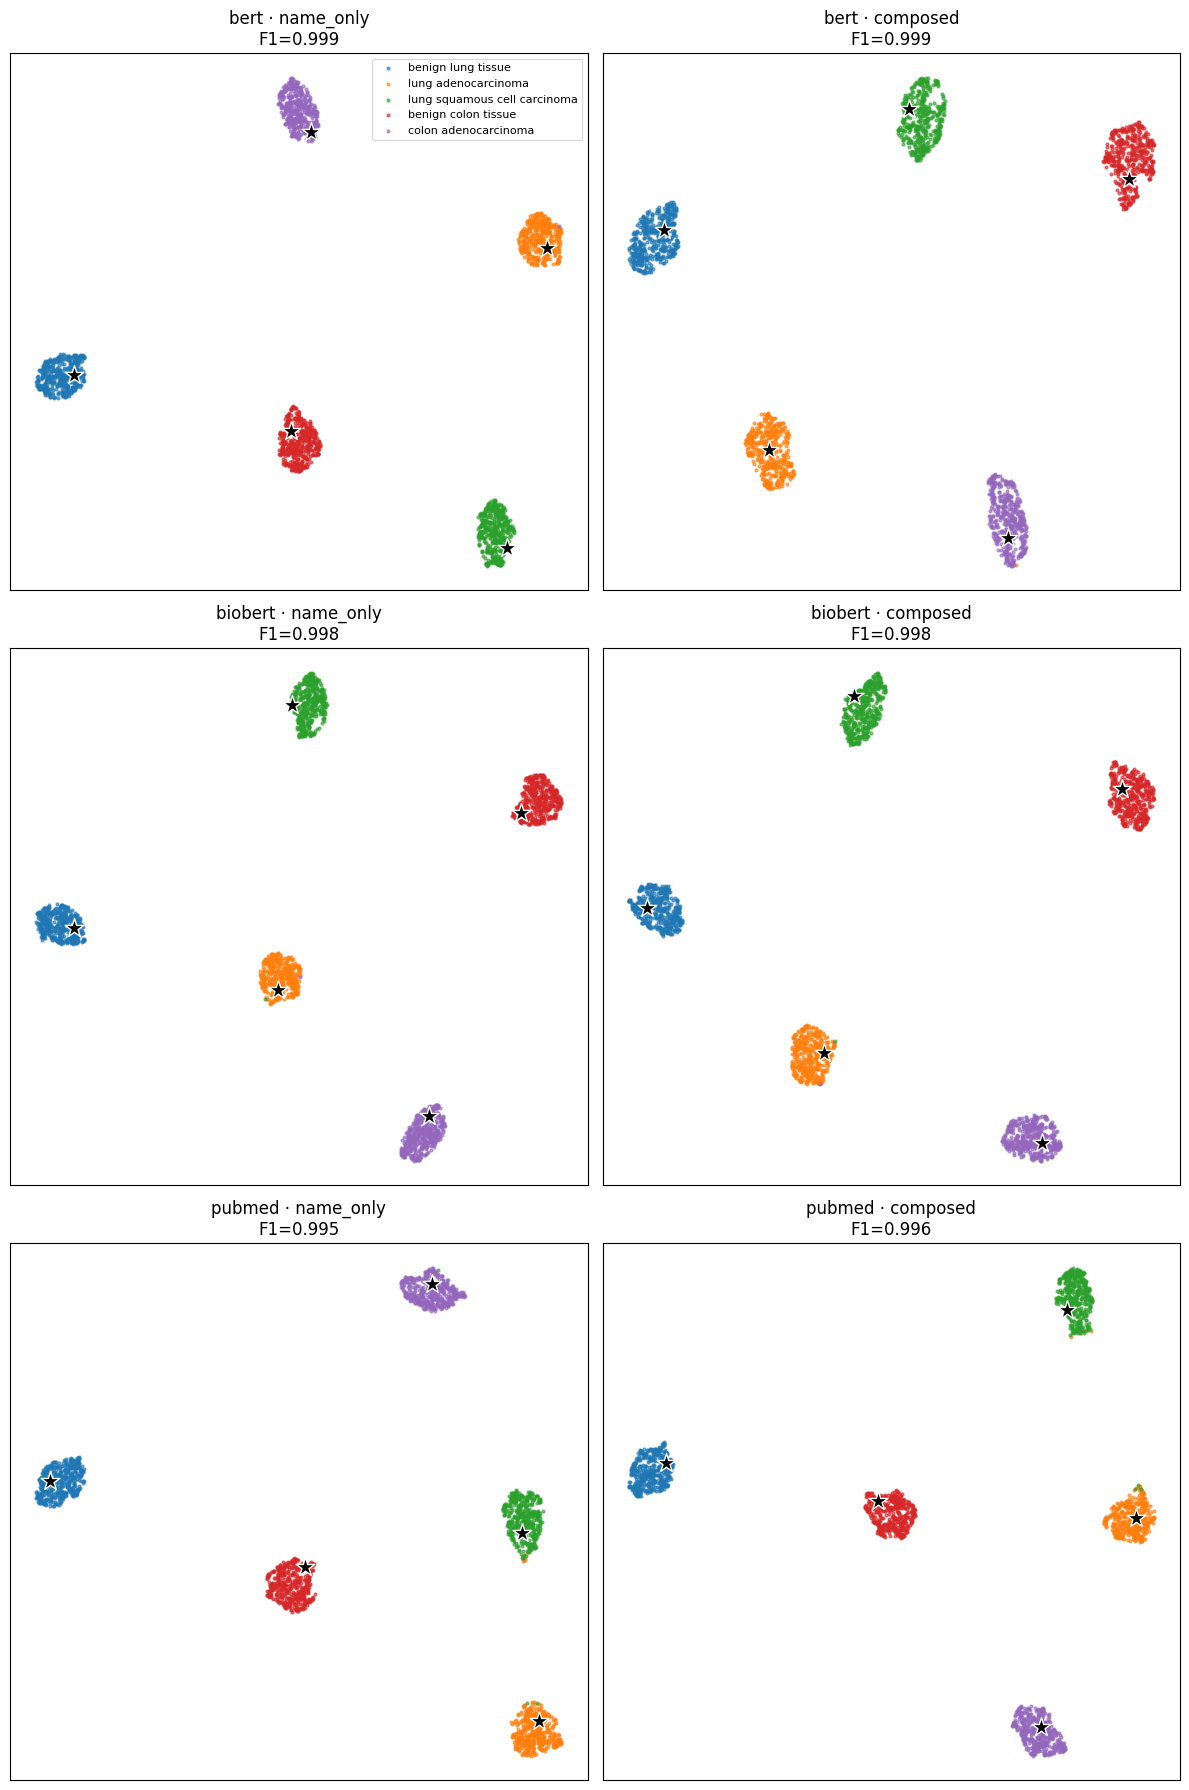

Saved -> /content/histopathology-clip-lab/results/plots/exp_06_biomed_text/umap_grid.png


In [19]:
# --- Cell 16: shared-UMAP grid (3 encoders x len(STRATEGIES) prompts) ---

n_rows = len(ENCODERS)
n_cols = len(STRATEGIES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
# Ensure axes is always 2D so axes[row][col] works for any matrix shape.
import numpy as _np
axes = _np.atleast_2d(axes)
if n_rows == 1:
    axes = axes.reshape(1, -1)
if n_cols == 1:
    axes = axes.reshape(-1, 1)

class_names_for_plot = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

for row_i, enc_key in enumerate(["bert", "biobert", "pubmed"]):
    for col_i, strategy in enumerate(STRATEGIES):
        cell_name = f"{enc_key}_{strategy}"
        ax = axes[row_i][col_i]
        img_2d, txt_2d = fit_shared_umap(
            all_image_embeddings[cell_name], all_text_embeddings[cell_name],
            n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED,
        )
        # Plot images with cluster colors.
        for cls_id in range(NUM_CLASSES):
            mask = (np.array(test_idx) == cls_id)
            ax.scatter(img_2d[mask, 0], img_2d[mask, 1], s=4, alpha=0.6,
                       label=class_names_for_plot[cls_id])
        # Plot prompts.
        ax.scatter(txt_2d[:, 0], txt_2d[:, 1], marker="*", s=200,
                   c="black", edgecolors="white", linewidths=1.0, zorder=5)
        ax.set_title(f"{enc_key} · {strategy}\nF1={all_results[cell_name]['macro_f1']:.3f}",
                     fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8, loc="best", framealpha=0.7)

plt.tight_layout()
grid_path = PLOTS_DIR / "umap_grid.png"
fig.savefig(grid_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {grid_path}")


In [20]:
# --- Cell 17: per-class F1 breakdown across cells ---
per_class_rows = []
for cell_name, encoder_id, strategy in ABLATION_GRID:
    m = all_results[cell_name]
    for cls_id in range(NUM_CLASSES):
        cls_name = INDEX_TO_NAME[cls_id]
        f1 = m["per_class"][cls_name]["f1-score"]
        per_class_rows.append({
            "cell": cell_name,
            "encoder": next(k for k, v in ENCODERS.items() if v == encoder_id),
            "strategy": strategy,
            "class": cls_name,
            "f1": f1,
        })
per_class_df = pd.DataFrame(per_class_rows)
per_class_pivot = per_class_df.pivot_table(index="class", columns="cell", values="f1")
print("Per-class F1 (rows=class, cols=cell):")
print(per_class_pivot.round(3).to_string())
per_class_pivot.to_csv(METRICS_DIR / "per_class_f1_grid.csv")


Per-class F1 (rows=class, cols=cell):
cell                          bert_composed  bert_name_only  biobert_composed  biobert_name_only  pubmed_composed  pubmed_name_only
class                                                                                                                              
benign colon tissue                   0.999           0.999             0.999              0.999            1.000             0.999
benign lung tissue                    1.000           1.000             1.000              1.000            1.000             1.000
colon adenocarcinoma                  0.998           0.997             0.997              0.997            0.999             0.998
lung adenocarcinoma                   0.998           0.998             0.997              0.997            0.990             0.989
lung squamous cell carcinoma          0.999           1.000             0.999              0.999            0.992             0.991


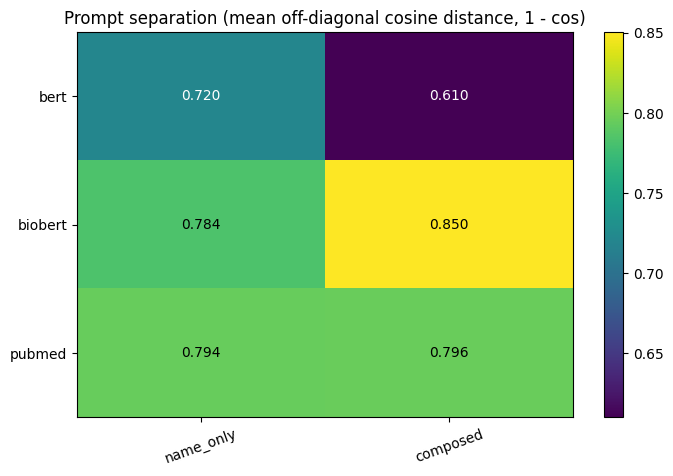

Saved -> /content/histopathology-clip-lab/results/plots/exp_06_biomed_text/prompt_separation.png


In [21]:
# --- Cell 18: prompt-separation diagnostic ---
# How distinct are the 5 class-prompt embeddings under each (encoder, strategy)?
# Larger value = more separated text vocabulary -> easier classification ceiling.

prompt_sep_pivot = summary_df.pivot(
    index="encoder", columns="strategy", values="prompt_separation"
).reindex(index=["bert", "biobert", "pubmed"], columns=list(STRATEGIES))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(prompt_sep_pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(STRATEGIES))); ax.set_yticks(range(3))
ax.set_xticklabels(STRATEGIES, rotation=20)
ax.set_yticklabels(["bert", "biobert", "pubmed"])
for i in range(3):
    for j in range(len(STRATEGIES)):
        v = prompt_sep_pivot.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v < prompt_sep_pivot.values.mean() else "black",
                fontsize=10)
ax.set_title("Prompt separation (mean off-diagonal cosine distance, 1 - cos)")
fig.colorbar(im, ax=ax)
sep_path = PLOTS_DIR / "prompt_separation.png"
fig.savefig(sep_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {sep_path}")


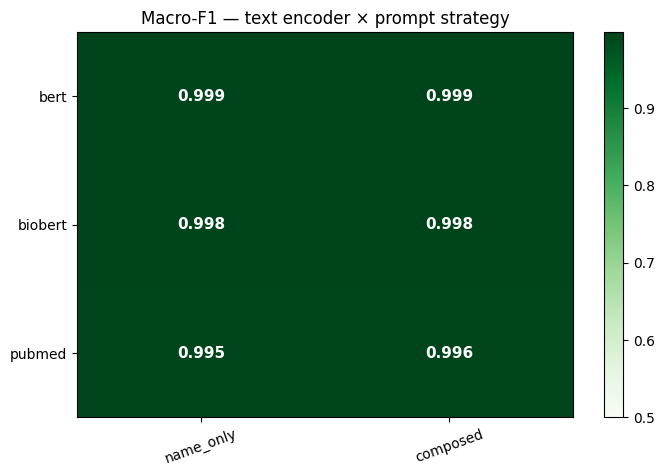

Saved -> /content/histopathology-clip-lab/results/plots/exp_06_biomed_text/macro_f1_heatmap.png


In [22]:
# --- Cell 19: macro-F1 heatmap ---
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="Greens", aspect="auto",
               vmin=0.5, vmax=max(0.75, pivot.values.max()))
ax.set_xticks(range(len(STRATEGIES))); ax.set_yticks(range(3))
ax.set_xticklabels(STRATEGIES, rotation=20)
ax.set_yticklabels(["bert", "biobert", "pubmed"])
for i in range(3):
    for j in range(len(STRATEGIES)):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v > 0.65 else "black", fontsize=11, fontweight="bold")
ax.set_title("Macro-F1 — text encoder × prompt strategy")
fig.colorbar(im, ax=ax)
f1_path = PLOTS_DIR / "macro_f1_heatmap.png"
fig.savefig(f1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {f1_path}")


## Summary

This notebook executes the 3 × 2 ablation matrix for RQ6 (multi_prompt is held in reserve — re-enable via `STRATEGIES`).

**Outputs persisted:**
- `results/metrics/exp_06_biomed_text/<cell>_classification.json` — global + per-class metrics
- `results/metrics/exp_06_biomed_text/summary.csv` — flat table across all 6 cells
- `results/metrics/exp_06_biomed_text/macro_f1_grid.csv` — pivoted (encoder × strategy)
- `results/metrics/exp_06_biomed_text/per_class_f1_grid.csv` — class × cell breakdown
- `results/plots/exp_06_biomed_text/umap_grid.png` — shared UMAP grid (one panel per cell)
- `results/plots/exp_06_biomed_text/macro_f1_heatmap.png` — headline visual
- `results/plots/exp_06_biomed_text/prompt_separation.png` — text-space diagnostic
- `results/confusion_matrices/exp_06_biomed_text/<cell>_cm_*.npy`
- `<RUN_DIR>/<cell>/weights.weights.h5` (on Drive / `local_drive/`) — cached projection weights

**Reading the matrix:**
- Compare *rows* to see what biomedical pretraining contributes given a fixed prompt format.
- Compare *columns* to see how prompt format interacts with each encoder.
- Use `prompt_separation` to diagnose whether a low F1 is bottlenecked by the
  encoder collapsing class prompts to a near-singular point — a CLIP-with-short-
  labels failure mode also documented for BERT-base in the v7 baseline UMAP.
